# Pseudotimes

We calculate pseudotimes and afterwards run the alignment of pseudotimes between cells and nuclei.
To do so we need cellalign. Instructions for installations just as future reference:

```
mamba install -c conda-forge r-dtw # in bash
install_github("shenorrLab/cellAlign", lib='environment/library/folder/for/R') # in R
```

In [2]:
%run ../Script/analysisLibraries

In [1]:
%run ../Script/pythonScripts.py

In [3]:
%matplotlib inline

In [4]:
%load_ext rpy2.ipython

In [5]:
adata = sc.read(f'./write/adata.norm.topo.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [6]:
#NUCLEI = sc.read('./write/MERGED_normalized_04.h5ad')
#CELL = sc.read('../../wholecell_samuele/write/qc/DGE_03.h5ad')

In [62]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

## Pseudotime for cells

### Palantir

In [9]:
import palantir

In [8]:
CELLS.obsm['X_pca'] = CELLS.obsm['X_DM'][:,0:50].copy()

In [10]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(CELLS, n_components=50)

In [11]:
ms_data = palantir.utils.determine_multiscale_space(CELLS)

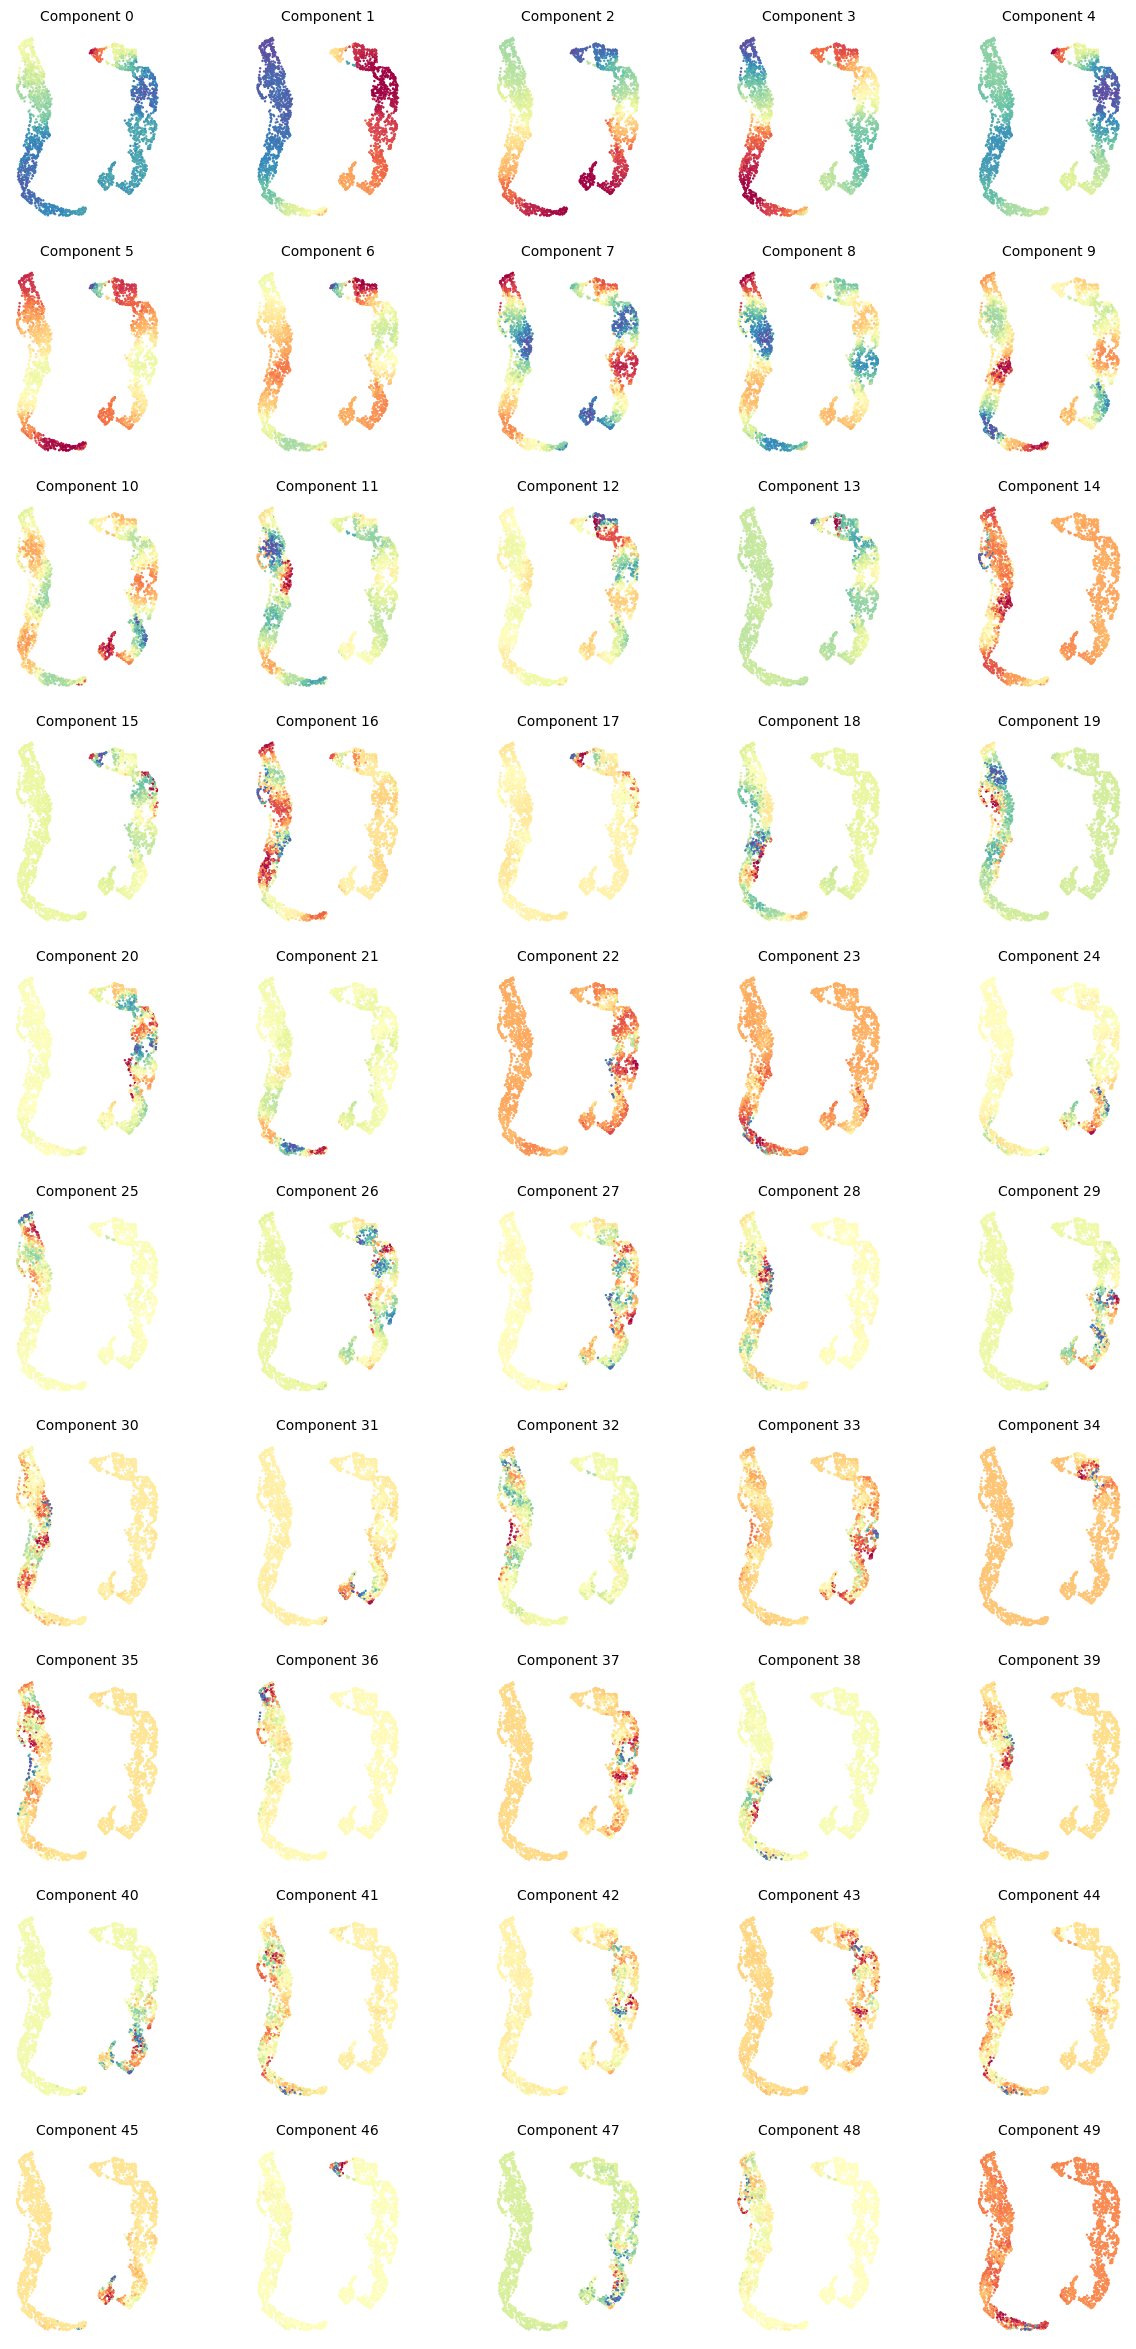

In [12]:
palantir.plot.plot_diffusion_components(CELLS)
plt.show()

Names for cells in spermatogoniaA to choose from

In [13]:
CELLS[CELLS.obs['clusters_single']=='SpermatogoniaA'].obs_names

Index(['AACCACAGTGCAGATG-Cells', 'AACGAAAGTACGACTT-Cells',
       'AACGGGATCACACCGG-Cells', 'AAGCATCTCACTAGCA-Cells',
       'AAGGTAATCTGGCCTT-Cells', 'AAGTACCCAAATGCTC-Cells',
       'AATCACGCAGAGTCTT-Cells', 'ACACTGAAGCTCGTGC-Cells',
       'ACATGCAAGGACGGAG-Cells', 'ACATGCATCCATACAG-Cells',
       'ACCCTCAGTTACCCTC-Cells', 'ACCTGAACACAATGTC-Cells',
       'ACGGTCGTCGAGTCCG-Cells', 'ACTGATGTCTCGTTTA-Cells',
       'ACTTAGGGTATGCTAC-Cells', 'AGAGAATGTGTTACAC-Cells',
       'AGCCAGCAGAAATGGG-Cells', 'AGCCAGCTCTGCGGCA-Cells',
       'AGCTCAATCCCAGGCA-Cells', 'AGGGAGTGTAAGTCAA-Cells',
       'AGTACCATCCCAGGCA-Cells', 'AGTAGCTTCGTCAGAT-Cells',
       'ATCACTTGTGACCGAA-Cells', 'ATCGTAGGTGGAACAC-Cells',
       'ATTACTCTCGGAAGGT-Cells', 'ATTCAGGTCTAAGAAG-Cells',
       'ATTCCTATCGACGCGT-Cells', 'CAGAGCCCATCACGGC-Cells',
       'CAGATCATCACCTGTC-Cells', 'CAGCCAGCATCGCTGG-Cells',
       'CAGGTATCATCCGATA-Cells', 'CAGTTCCGTTATTCCT-Cells',
       'CATCGCTCAAACGTGG-Cells', 'CATGCTCCACAGTACT-Cells

In [18]:
start_cell = 'TTGGGTATCTTTGGAG-Cells'
pr_res = palantir.core.run_palantir( CELLS, early_cell=start_cell, 
                                    knn=20, seed=123, num_waypoints=100, 
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.00014243125915527343 minutes
Determining pseudotime...
Shortest path distances using 20-nearest neighbor graph...
Time for shortest paths: 0.013600699106852214 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9998
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


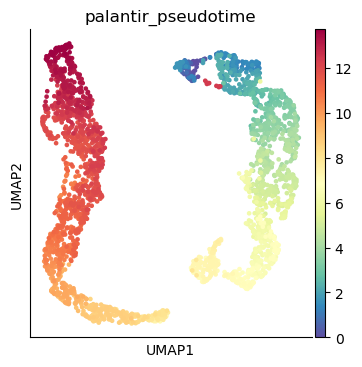

In [19]:
sc.pl.umap(CELLS, color=['palantir_pseudotime'])

In [22]:
CELLS.obs['dpt_palantir']=CELLS.obs['palantir_pseudotime']/max(CELLS.obs['palantir_pseudotime'])

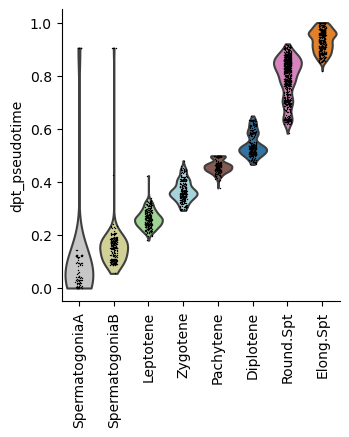

In [21]:
sc.pl.violin(CELLS, keys='dpt_palantir', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

In [23]:
avoid = ((CELLS.obs['clusters_single']=='SpermatogoniaA')&(CELLS.obs['dpt_palantir']>.2))|((CELLS.obs['clusters_single']=='SpermatogoniaB')&(CELLS.obs['dpt_palantir']>.3))
CELLS = CELLS[ np.invert(avoid) ].copy()

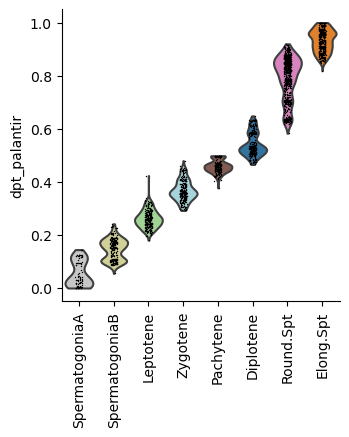

In [24]:
sc.pl.violin(CELLS, keys='dpt_palantir', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

## Pseudotime for nuclei

### Palantir

In [25]:
import palantir

In [26]:
NUCLEI.obsm['X_pca'] = NUCLEI.obsm['X_DM'][:,0:50].copy()

In [30]:
NUCLEI.obs.clusters_single.cat.categories

Index(['Diplotene', 'Elong.Spt', 'Leptotene', 'Myoid', 'Pachytene',
       'Round.Spt', 'SpermatogoniaA', 'SpermatogoniaB', 'Zygotene'],
      dtype='object')

In [32]:
NUCLEI_2 = NUCLEI[ [i not in ['Myoid'] for i in NUCLEI.obs['clusters_single']] ].copy()

In [33]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(NUCLEI_2, n_components=50)

In [34]:
ms_data = palantir.utils.determine_multiscale_space(NUCLEI_2)

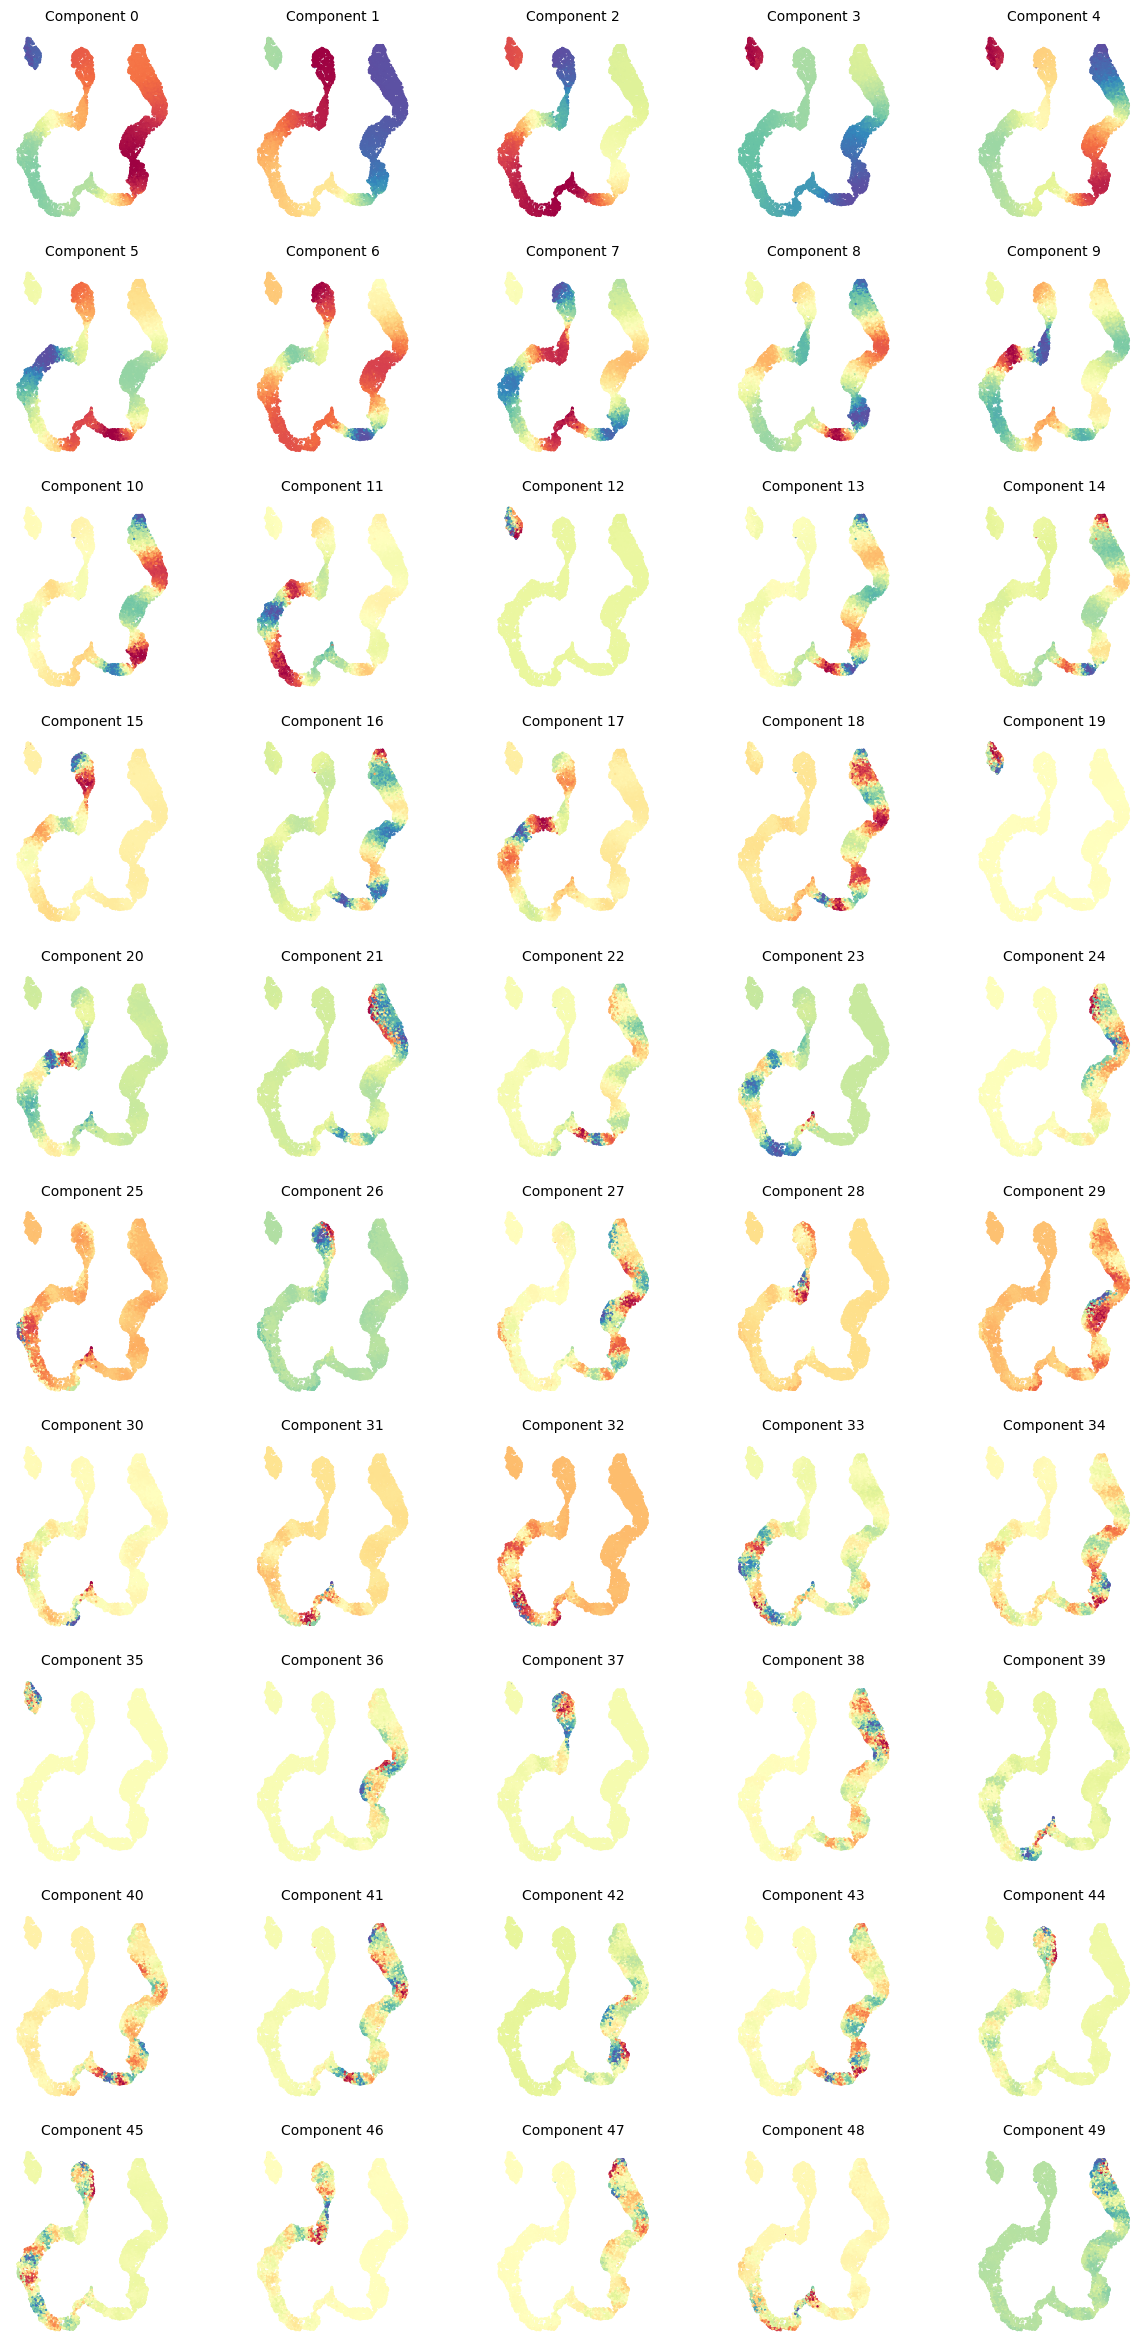

In [35]:
palantir.plot.plot_diffusion_components(NUCLEI_2)
plt.show()

Names for nuclei in spermatogoniaA to choose from

In [36]:
NUCLEI_2[NUCLEI_2.obs['clusters_single']=='SpermatogoniaA'].obs_names

Index(['AAACCCACAGATCCTA-Nuclei', 'AAACGCTGTTCCATTT-Nuclei',
       'AAAGAACGTCAACCTA-Nuclei', 'AAAGGGCTCCTGCCAT-Nuclei',
       'AAAGTGATCTGAGTCA-Nuclei', 'AACAACCAGGGACTGT-Nuclei',
       'AACAGGGTCCACGAAT-Nuclei', 'AACCCAAAGCCGTTAT-Nuclei',
       'AACGGGAAGGATCACG-Nuclei', 'AACGGGACACCGCTAG-Nuclei',
       ...
       'TTGTGGAGTCTTGAGT-Nuclei', 'TTGTGTTCAAGCACCC-Nuclei',
       'TTGTGTTCACGCTGAC-Nuclei', 'TTGTTGTAGAAGGATG-Nuclei',
       'TTGTTTGAGTGGAAGA-Nuclei', 'TTTACCATCTAGTTCT-Nuclei',
       'TTTCACACACCGTACG-Nuclei', 'TTTCACATCAGCAATC-Nuclei',
       'TTTCATGGTGACCTGC-Nuclei', 'TTTCCTCAGAGTCAAT-Nuclei'],
      dtype='object', length=642)

In [37]:
start_cell = 'AAAGAACGTCAACCTA-Nuclei'
pr_res = palantir.core.run_palantir( NUCLEI_2, early_cell=start_cell, 
                                    knn=50, seed=123, num_waypoints=100, 
)

Sampling and flocking waypoints...
Time for determining waypoints: 0.00023649533589680988 minutes
Determining pseudotime...
Shortest path distances using 50-nearest neighbor graph...
Time for shortest paths: 0.15627289613087972 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


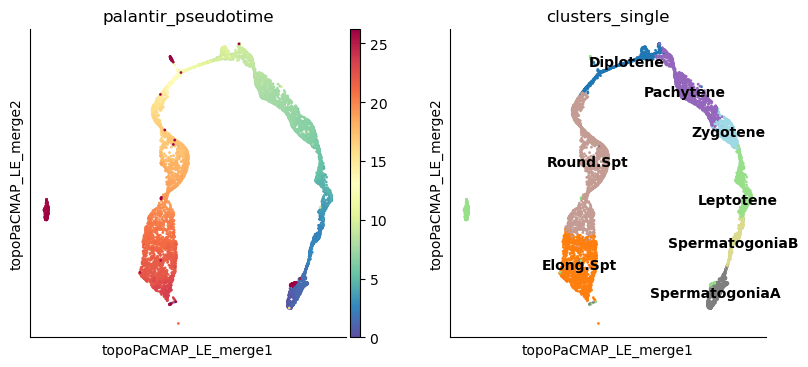

In [38]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    NUCLEI_2,
    basis="topoPaCMAP_LE_merge",
    color=['palantir_pseudotime', 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

In [39]:
NUCLEI_2.obs['dpt_palantir']=NUCLEI_2.obs['palantir_pseudotime']/max(NUCLEI_2.obs['palantir_pseudotime'])

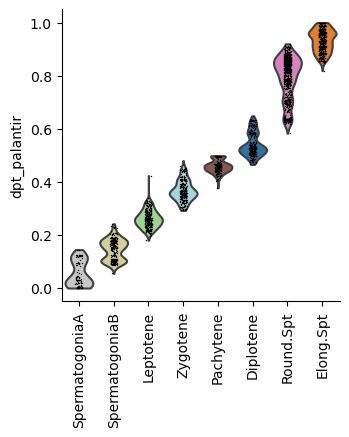

In [40]:
sc.pl.violin(CELLS, keys='dpt_palantir', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

In [42]:
avoid2 = ((NUCLEI_2.obs['clusters_single']=='SpermatogoniaA')&(NUCLEI_2.obs['dpt_palantir']>.2)) |\
         ((NUCLEI_2.obs['clusters_single']=='SpermatogoniaB')&(NUCLEI_2.obs['dpt_palantir']>.3)) |\
         ((NUCLEI_2.obs['clusters_single']=='Leptotene')&(NUCLEI_2.obs['dpt_palantir']>.4)) |\
         ((NUCLEI_2.obs['clusters_single']=='Zygotene')&(NUCLEI_2.obs['dpt_palantir']>.5)) |\
         ((NUCLEI_2.obs['clusters_single']=='Pachytene')&(NUCLEI_2.obs['dpt_palantir']>.6)) |\
         ((NUCLEI_2.obs['clusters_single']=='Diplotene')&(NUCLEI_2.obs['dpt_palantir']>.7)) |\
         ((NUCLEI_2.obs['clusters_single']=='Round.Spt')&(NUCLEI_2.obs['dpt_palantir']>.95))
NUCLEI_2 = NUCLEI_2[ np.invert(avoid2) ].copy()

Note now we put the pseudotimes in the dataset NUCLEI with value -1 for the myoid cells

In [63]:
dpt_palantir_new = pd.Series(index=NUCLEI.obs_names)
dpt_palantir_new[NUCLEI_2.obs_names] = NUCLEI_2.obs.dpt_palantir
dpt_palantir_new[ [i not in NUCLEI_2.obs_names for i in NUCLEI.obs_names]  ] = -1

In [64]:
NUCLEI.obs['dpt_palantir'] = dpt_palantir_new.copy()

Remove the outliers but keep the myoids

In [65]:
NUCLEI = NUCLEI[ np.concatenate( [np.array(NUCLEI_2.obs_names), np.array(NUCLEI[ [i in ['Myoid'] for i in NUCLEI.obs.clusters_single] ].obs_names)]) ].copy()

In [66]:
adata = adata[ np.concatenate( [np.array(NUCLEI.obs_names),np.array(CELLS.obs_names)] ) ].copy()

In [67]:
adata.shape

(9956, 23544)

In [68]:
adata.obs['dpt_palantir'] = np.concatenate( (NUCLEI.obs['dpt_palantir'],CELLS.obs['dpt_palantir']) )

## Pseudotime alignment


subsetting the data

In [95]:
adata_flt = adata[:,adata.var.highly_variable].copy()

In [96]:
adata_flt = adata_flt[ [i not in ['Myoid'] for i in adata_flt.obs.clusters_single] ].copy()

In [97]:
adata_flt.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, soupx_Z_counts, soupx_counts, spliced, unspliced

In [98]:
adata_flt.X = adata_flt.layers['SCT_counts'].copy()
#sc.pp.scale(adata_flt)

preparing all the things to pass to R

- cells and nuclei matrices

In [99]:
cellMat=adata_flt[adata_flt.obs['batch']=='Cells'].X.copy()

In [100]:
nucMat=adata_flt[adata_flt.obs['batch']=='Nuclei'].X.copy()

- barcode names

In [101]:
cellNames = np.array(adata_flt[adata_flt.obs['batch']=='Cells'].obs_names)

In [102]:
nucNames = np.array(adata_flt[adata_flt.obs['batch']=='Nuclei'].obs_names)

- pseudotimes

In [109]:
cellT = np.array(adata_flt[ [i in ['Cells'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

In [110]:
nucT = np.array(adata_flt[ [i in ['Nuclei'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

Running `cellAlign` in `R`

- create the two objects with pseudotimes 

In [111]:
%%R -i cellMat -i nucMat -i cellT -i nucT -i nucNames -i cellNames

library(cellAlign)

cellT = as.numeric(cellT)
nucT = as.numeric(nucT)
#give names to the matrices (invert rows and cols when used as input)
names(cellT) = cellNames
names(nucT) = nucNames
rownames(cellMat) = cellNames; #colnames(cellMat) = genes_inters
rownames(nucMat) = nucNames; #colnames(nucMat) = genes_inters

#number of alignment points when binning time interval
numPts = 50
#Cell data
cellData = cellAlign::interWeights(expDataBatch = t(cellMat), trajCond = cellT,
                                         winSz = 0.1, numPts = numPts)
#Nuclei data
nucData = cellAlign::interWeights(expDataBatch = t(nucMat), trajCond = nucT,
                                         winSz = 0.1, numPts = numPts)

- calculate the trajectory

In [112]:
%%R

require(ggplot2)
require(reshape2)
require(pheatmap)

# this is just to plot rudimentally the behaviour of a chosen gene (first in the list). 
#T he behaviour will actually be modelled with 
# a GAM, but what we do here is just representative

#sharedMarkers = intersect(rownames(t(cellMat)), rownames(t(nucMat)))
#whichgene=sharedMarkers[100]
selectedCell<-cellData$interpolatedVals[1,]#[whichgene,]
selectedNuc<-nucData$interpolatedVals[1,]#[whichgene,]

dfCelli = data.frame(traj = cellData$traj, value=c(selectedCell), error=c(cellData$error[1,]))
dfCell = data.frame(traj = cellT, cellMat[,1])
dfNuci = data.frame(traj = nucData$traj, value=c(selectedNuc), error=c(nucData$error[1,]))
dfNuc = data.frame(traj = nucT, nucMat[,1])
dfCellM = melt(dfCell, id.vars = 'traj')
dfNucM = melt(dfNuc, id.vars = 'traj')


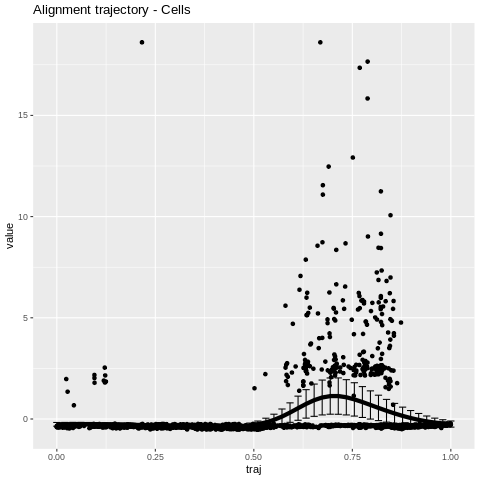

In [113]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfCelli, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfCellM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Cells") 

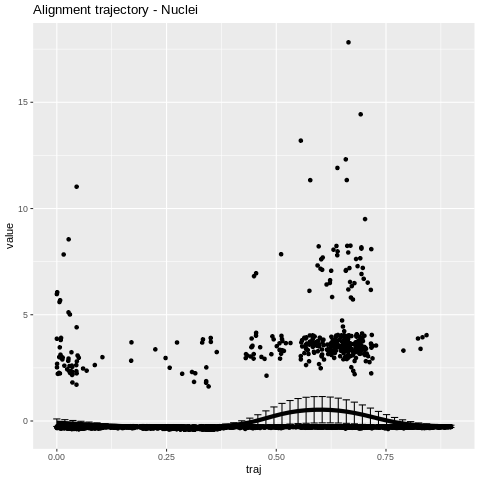

In [114]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfNuci, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfNucM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Nuclei") 

- plot the distances between bins of pseudotimes

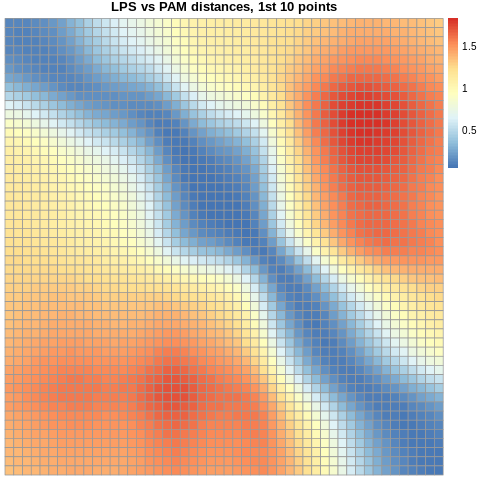

In [115]:
%%R
A=calcDistMat(nucData$interpolatedVals,cellData$interpolatedVals, dist.method = 'Cosine')
pheatmap(A, cluster_cols = F, cluster_rows=F, main = "LPS vs PAM distances, 1st 10 points",
          show_rownames = T, show_colnames = T,display_numbers = F)

R[write to console]: calculate dissimilarity matrix

R[write to console]: calculate cost and step matrices

R[write to console]: backtracking



[1] NA


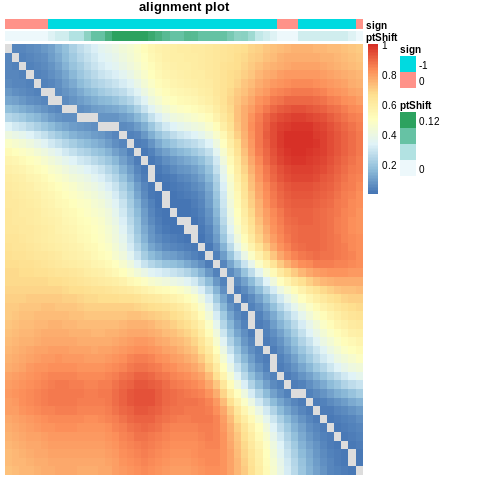

In [116]:
%%R

alignment = globalAlign(nucData$interpolatedVals, cellData$interpolatedVals,
                                   scores = list(query = nucData$traj, 
                                                 ref = cellData$traj),
                                   sigCalc = F, numPerm = 20, dist.method = "Cosine")
plotAlign(alignment)

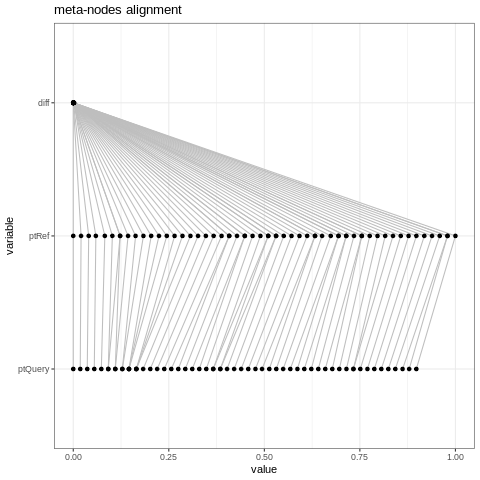

In [117]:
%%R

mapping = mapRealDataGlobal(alignment,intTrajQuery = nucData$traj, realTrajQuery = nucT,
                            intTrajRef = cellData$traj, realTrajRef = cellT)
plotMapping(mapping)

In [118]:
%%R -o mapping
ls(mapping)

[1] "metaNodesPt" "queryAssign" "refAssign"  


In [119]:
mapping['metaNodesPt']['diff']

1     0.000000
2     0.000070
3     0.000430
4     0.002154
5     0.000794
6     0.000241
7     0.000136
8     0.000064
9     0.000502
10    0.000302
11    0.000298
12    0.000641
13    0.000634
14    0.000673
15    0.000242
16    0.000066
17    0.000285
18    0.000235
19    0.000109
20    0.000212
21    0.000532
22    0.000153
23    0.000161
24    0.000088
25    0.000011
26    0.000052
27    0.000002
28    0.000039
29    0.000095
30    0.000084
31    0.000122
32    0.000711
33    0.000101
34    0.000039
35    0.000252
36    0.000518
37    0.000623
38    0.000035
39    0.001875
40    0.000596
41    0.000178
42    0.000021
43    0.000044
44    0.000037
45    0.000116
46    0.000059
47    0.000007
48    0.000244
49    0.000003
50    0.000241
51    0.000276
52    0.000185
53    0.000230
54    0.000125
55    0.000307
56    0.000003
57    0.000318
58    0.001053
59    0.000050
60    0.000000
Name: diff, dtype: float64

In [120]:
cellDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptRef']), 
                      index=mapping['metaNodesPt']['metaNodeRef']  )

In [121]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptQuery']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [122]:
nucNodes = pd.Series(index=nucNames)
cellNodes = pd.Series(index=cellNames)
for n,c,Tn,Tc in zip(nucDF.index, cellDF.index, nucDF[0], cellDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn
    cellNodes[ mapping['refAssign'][c] ] = Tc

In [123]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.824501
AAACCCACAGATCCTA-Nuclei    0.018276
AAACCCAGTTAGTCGT-Nuclei    0.238113
AAACGAAAGAGCATAT-Nuclei    0.366263
AAACGAAAGCTATCCA-Nuclei    0.256516
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.861837
TTTGTTGGTCCAGCAC-Nuclei    0.457904
TTTGTTGGTCCGTACG-Nuclei    0.622915
TTTGTTGTCGTACACA-Nuclei    0.238113
TTTGTTGTCTGGCCGA-Nuclei    0.128401
Length: 7212, dtype: float64

How to check Nan in the alignment and correction with the nearest neighbour (not a problem in this case)

In [124]:
idxNan = nucNodes.index[ np.where(np.isnan(nucNodes)) ]

In [125]:
idxNan

Index([], dtype='object')

In [126]:
idxNan = cellNodes.index[ np.where(np.isnan(cellNodes)) ]

In [127]:
idxNan

Index([], dtype='object')

correction:

In [128]:
#dist = pd.DataFrame( NUCLEI.uns['neighbors']['distances'].todense(), 
#                    index=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names,
#                    columns=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names )


In [129]:
#for i in idxNan:
#    gzero = dist.loc[i,:][ dist.loc[i,:]>0 ]
#    nucNodes.loc[ i ] = nucNodes.loc[ np.argmin(gzero) ]

Copying all the binned aligned pseudotimes in the original data object

In [130]:
concatTime = pd.concat([nucNodes, cellNodes])

In [132]:
dpt_cellalign_new = pd.Series(index=adata.obs_names)
dpt_cellalign_new[adata_flt.obs_names] = concatTime

In [133]:
dpt_cellalign_new[ [i not in adata_flt.obs_names for i in dpt_cellalign_new.index] ] = -1

In [135]:
adata.obs['dpt_palantir_cellalign'] = dpt_cellalign_new.copy()

Some fancy plots

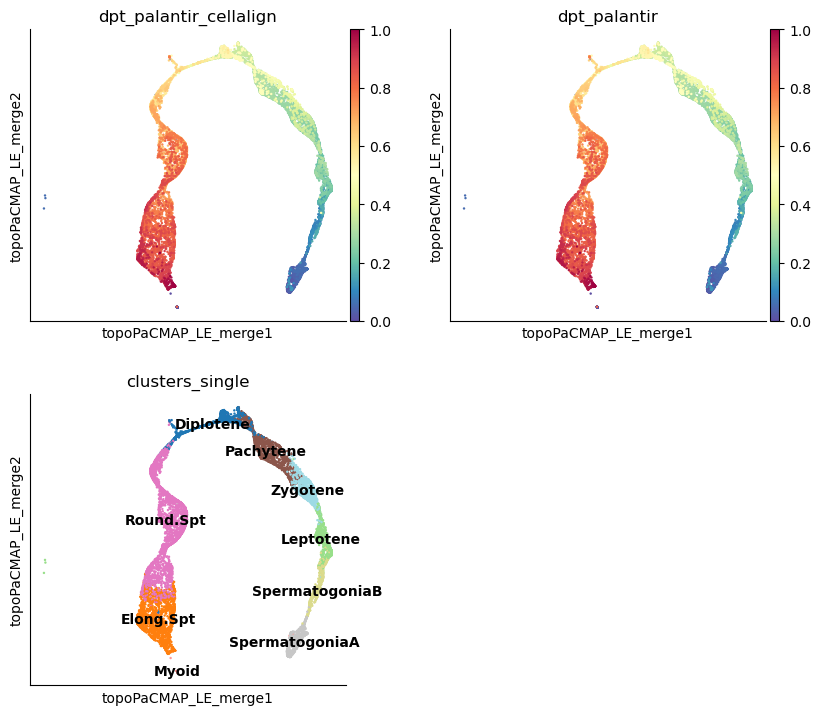

In [137]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=['dpt_palantir_cellalign', 'dpt_palantir', 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
    vmin=0
)

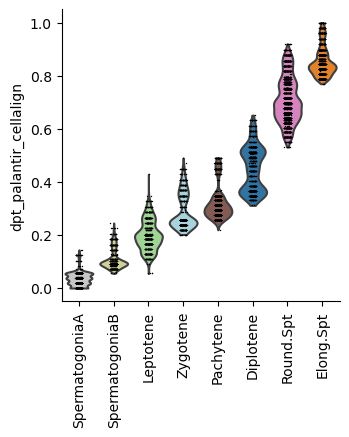

In [138]:
sc.pl.violin(adata, keys='dpt_palantir_cellalign', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

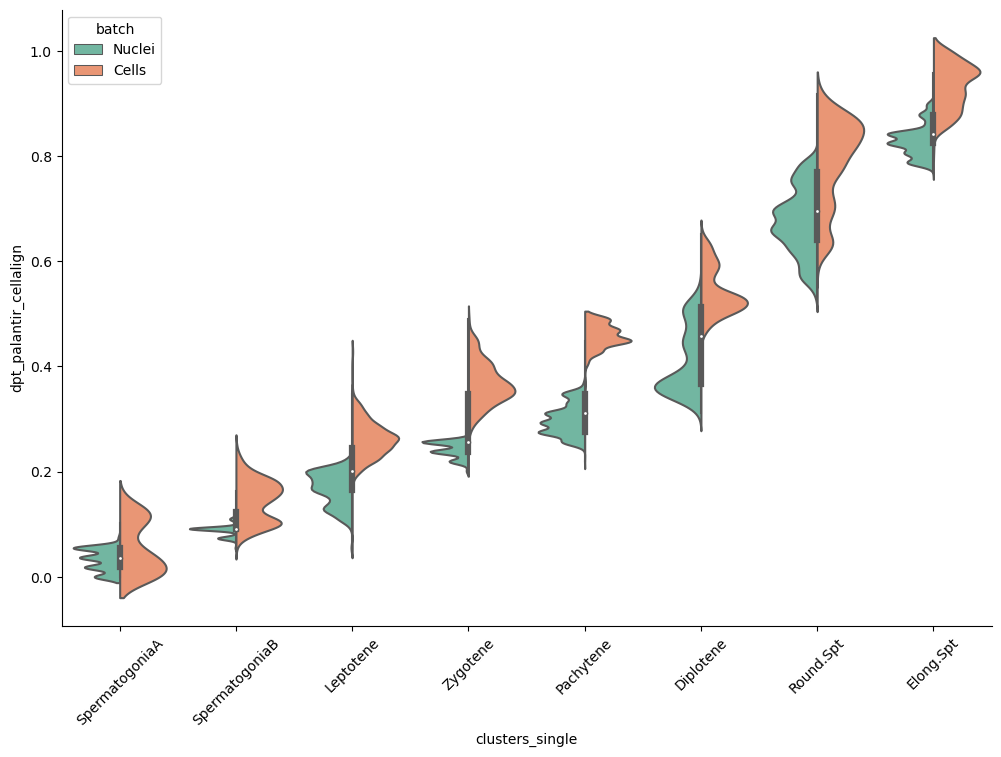

In [140]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir_cellalign", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir_cellalign', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

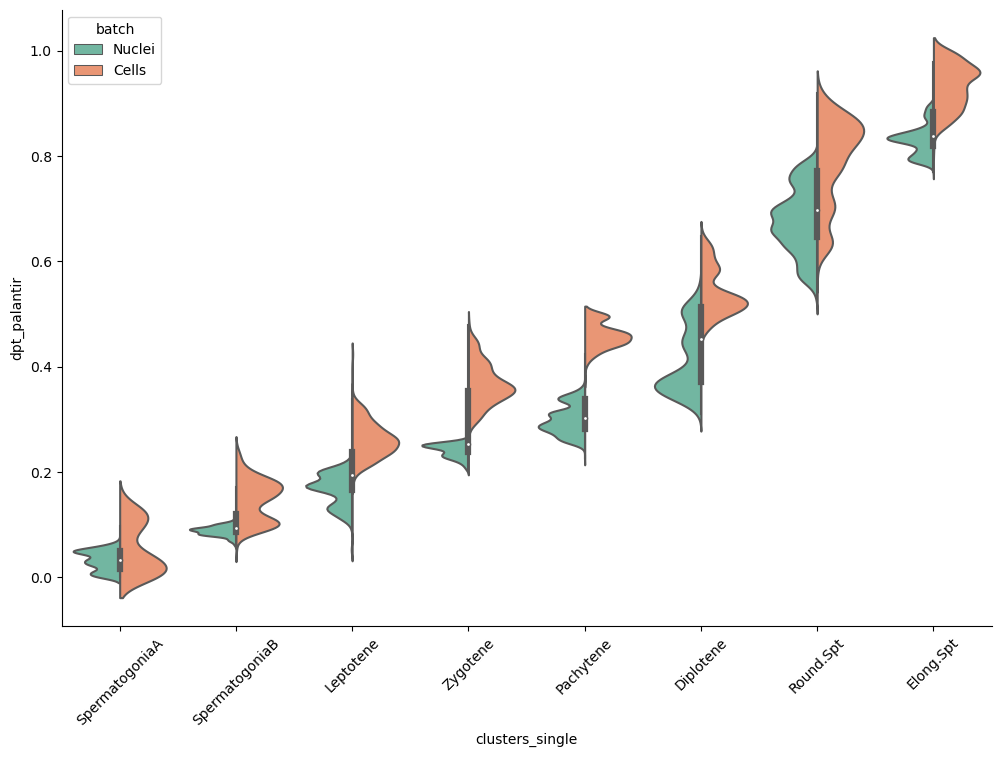

In [142]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

In [143]:
adata.write('./write/adata.dpt.h5ad')

We also look at size of differences between pseudotimes to see the size of the correction

In [ ]:
adata = sc.read('./write/adata.dpt.h5ad')

In [144]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['diff']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [145]:
nucNodes = pd.Series(index=nucNames)
for n,Tn in zip(nucDF.index, nucDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn

In [146]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.000003
AAACCCACAGATCCTA-Nuclei    0.000070
AAACCCAGTTAGTCGT-Nuclei    0.000532
AAACGAAAGAGCATAT-Nuclei    0.000095
AAACGAAAGCTATCCA-Nuclei    0.000153
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.001053
TTTGTTGGTCCAGCAC-Nuclei    0.000252
TTTGTTGGTCCGTACG-Nuclei    0.000037
TTTGTTGTCGTACACA-Nuclei    0.000532
TTTGTTGTCTGGCCGA-Nuclei    0.000298
Length: 7212, dtype: float64

In [150]:
NUCLEI.obs['dpt_diff'] = [nucNodes[i] if i in nucNodes.index 
                          else -1
                          for i in NUCLEI.obs_names]

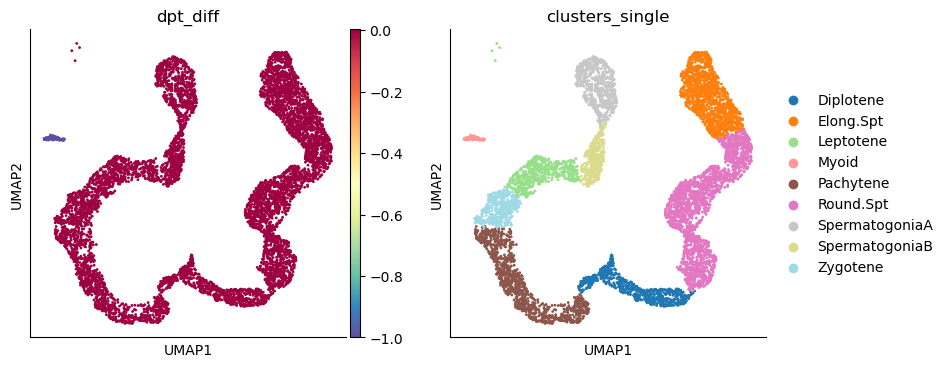

In [151]:
sc.pl.umap(NUCLEI, color=['dpt_diff','clusters_single'])

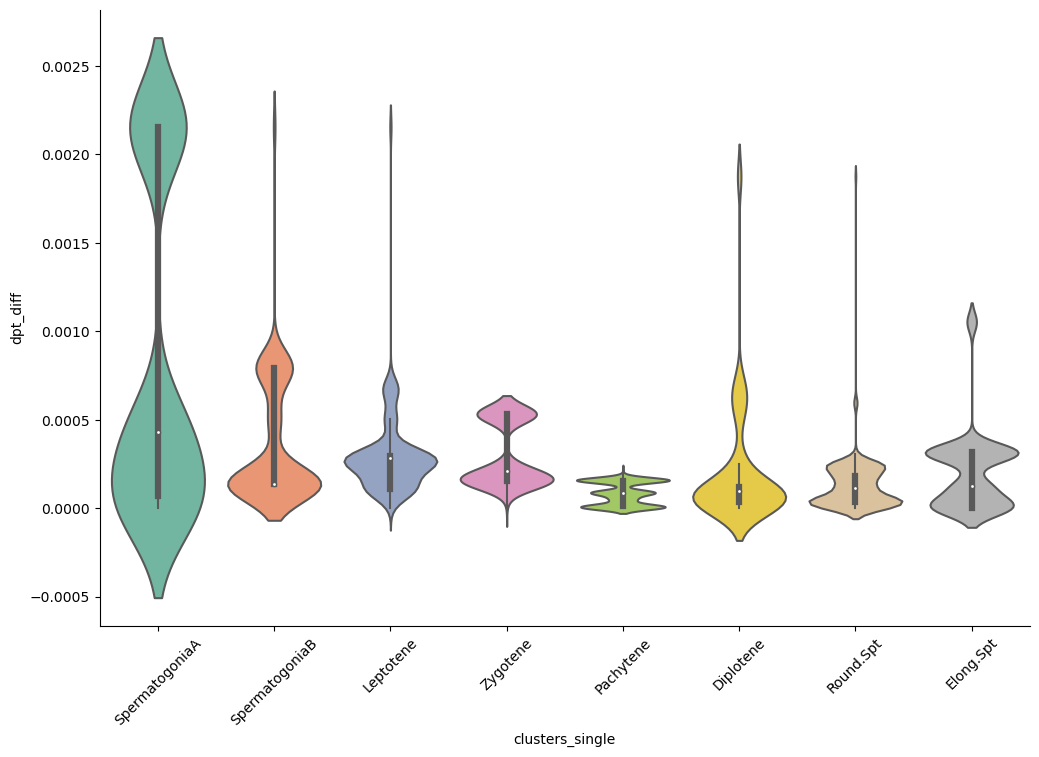

In [152]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_diff", 
                    scale="width", palette="Set2", ax=ax1,                    
                    data=NUCLEI.obs[ ['dpt_diff', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

Almost no corrections in the alignment

## With imputation

Testing the pseudotimes adding imputation with MAGIC to see how pseudotimes change for nuclei, and if the differences by clusters are due to dropouts

In [5]:
adata = sc.read('./write/adata.dpt.h5ad')

In [6]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

In [7]:
import magic

In [8]:
magic_op = magic.MAGIC()

imputation

In [9]:
CELLS_magic = magic_op.fit_transform( np.array(CELLS.layers['soupx_counts']) )

Calculating MAGIC...
  Running MAGIC on 2676 cells and 23544 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 7.39 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.54 seconds.
    Calculating affinities...
    Calculated affinities in 0.59 seconds.
  Calculated graph and diffusion operator in 8.57 seconds.
  Running MAGIC with `solver='exact'` on 23544-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 8.69 seconds.
Calculated MAGIC in 17.29 seconds.


In [10]:
CELLS.layers['soupx_magic_counts'] = CELLS_magic.copy()

In [11]:
NUCLEI_magic = magic_op.fit_transform( np.array(NUCLEI.layers['soupx_counts']) )

Calculating MAGIC...
  Running MAGIC on 7280 cells and 23544 genes.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 19.45 seconds.
    Calculating KNN search...
    Calculated KNN search in 3.43 seconds.
    Calculating affinities...
    Calculated affinities in 3.45 seconds.
  Calculated graph and diffusion operator in 26.33 seconds.
  Running MAGIC with `solver='exact'` on 23544-dimensional data may take a long time. Consider denoising specific genes with `genes=<list-like>` or using `solver='approximate'`.
  Calculating imputation...
  Calculated imputation in 82.72 seconds.
Calculated MAGIC in 109.13 seconds.


In [12]:
NUCLEI.layers['soupx_magic_counts'] = NUCLEI_magic.copy()

Put together the two imputations in the original object

In [13]:
adata.layers['soupx_magic_counts'] = adata.X.copy()
adata[ adata.obs['batch']=='Cells', :].layers['soupx_magic_counts'] = CELLS.layers['soupx_magic_counts']
adata[ adata.obs['batch']=='Nuclei', :].layers['soupx_magic_counts'] = NUCLEI.layers['soupx_magic_counts']
adata.layers['soupx_magic_counts'][adata.layers['soupx_magic_counts']<=0] = 0

In [14]:
adata.X = adata.layers['soupx_magic_counts'].copy()

In [15]:
CELLS.X = CELLS.layers['soupx_magic_counts'].copy()

In [16]:
sc.pp.normalize_total(CELLS)
sc.pp.log1p(CELLS)
sc.pp.highly_variable_genes(CELLS)
sc.pp.scale(CELLS, max_value=10)

In [17]:
NUCLEI.X = NUCLEI.layers['soupx_magic_counts'].copy()

In [18]:
sc.pp.normalize_total(NUCLEI)
sc.pp.log1p(NUCLEI)
sc.pp.highly_variable_genes(NUCLEI)
sc.pp.scale(NUCLEI, max_value=10)

## Pseudotime alignment


subsetting the data

In [19]:
adata_flt = adata[:, CELLS.var.highly_variable | NUCLEI.var.highly_variable].copy()

In [20]:
adata_flt = adata_flt[ [i not in ['Myoid'] for i in adata_flt.obs.clusters_single] ].copy()

In [21]:
adata_flt.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, soupx_Z_counts, soupx_counts, spliced, unspliced, soupx_magic_counts

In [22]:
adata_flt.X = adata_flt.layers['soupx_magic_counts'].copy()
#sc.pp.scale(adata_flt)

In [23]:
sc.pp.normalize_total(adata_flt)
sc.pp.log1p(adata_flt)
sc.pp.scale(adata_flt, max_value=10)

In [35]:
CELLS = CELLS[ [i not in ['Myoid'] for i in CELLS.obs.clusters_single] ].copy()
NUCLEI = NUCLEI[ [i not in ['Myoid'] for i in NUCLEI.obs.clusters_single] ].copy()

preparing all the things to pass to R

- cells and nuclei matrices

In [36]:
#cellMat=adata_flt[adata_flt.obs['batch']=='Cells'].X.copy()
cellMat=CELLS[:, CELLS.var.highly_variable | NUCLEI.var.highly_variable].X.copy()

In [37]:
#nucMat=adata_flt[adata_flt.obs['batch']=='Nuclei'].X.copy()
nucMat=NUCLEI[:, CELLS.var.highly_variable | NUCLEI.var.highly_variable].X.copy()

- barcode names

In [38]:
cellNames = np.array(adata_flt[adata_flt.obs['batch']=='Cells'].obs_names)

In [39]:
nucNames = np.array(adata_flt[adata_flt.obs['batch']=='Nuclei'].obs_names)

- pseudotimes

In [40]:
cellT = np.array(adata_flt[ [i in ['Cells'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

In [41]:
nucT = np.array(adata_flt[ [i in ['Nuclei'] for i in adata_flt.obs.batch] ].obs['dpt_palantir'])

Running `cellAlign` in `R`

- create the two objects with pseudotimes 

In [42]:
%%R -i cellMat -i nucMat -i cellT -i nucT -i nucNames -i cellNames

library(cellAlign)

cellT = as.numeric(cellT)
nucT = as.numeric(nucT)
#give names to the matrices (invert rows and cols when used as input)
names(cellT) = cellNames
names(nucT) = nucNames
rownames(cellMat) = cellNames; #colnames(cellMat) = genes_inters
rownames(nucMat) = nucNames; #colnames(nucMat) = genes_inters

#number of alignment points when binning time interval
numPts = 50
#Cell data
cellData = cellAlign::interWeights(expDataBatch = t(cellMat), trajCond = cellT,
                                         winSz = 0.1, numPts = numPts)
#Nuclei data
nucData = cellAlign::interWeights(expDataBatch = t(nucMat), trajCond = nucT,
                                         winSz = 0.1, numPts = numPts)

- calculate the trajectory

In [43]:
%%R

require(ggplot2)
require(reshape2)
require(pheatmap)

# this is just to plot rudimentally the behaviour of a chosen gene (first in the list). 
#T he behaviour will actually be modelled with 
# a GAM, but what we do here is just representative

#sharedMarkers = intersect(rownames(t(cellMat)), rownames(t(nucMat)))
#whichgene=sharedMarkers[100]
selectedCell<-cellData$interpolatedVals[1,]#[whichgene,]
selectedNuc<-nucData$interpolatedVals[1,]#[whichgene,]

dfCelli = data.frame(traj = cellData$traj, value=c(selectedCell), error=c(cellData$error[1,]))
dfCell = data.frame(traj = cellT, cellMat[,1])
dfNuci = data.frame(traj = nucData$traj, value=c(selectedNuc), error=c(nucData$error[1,]))
dfNuc = data.frame(traj = nucT, nucMat[,1])
dfCellM = melt(dfCell, id.vars = 'traj')
dfNucM = melt(dfNuc, id.vars = 'traj')


R[write to console]: Loading required package: ggplot2

R[write to console]: RStudio Community is a great place to get help:
https://community.rstudio.com/c/tidyverse

R[write to console]: Loading required package: reshape2

R[write to console]: Loading required package: pheatmap



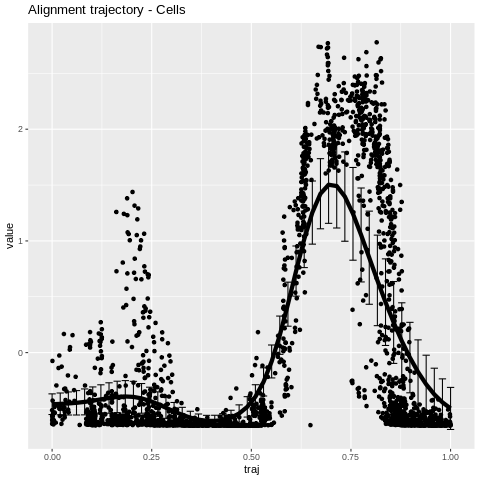

In [44]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfCelli, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfCellM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Cells") 

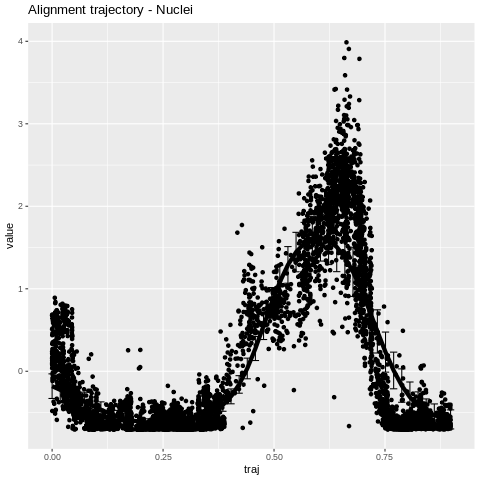

In [45]:
%%R

#plot of an example gene and its interpolation with error bars
ggplot(dfNuci, aes(x=traj,y=value)) +  
    geom_errorbar(aes(ymin=value-error/2, ymax=value+error/2)) + 
    geom_line(size = 2) + 
    geom_point(data=dfNucM, aes(x=traj,y=value)) + 
    ggtitle("Alignment trajectory - Nuclei") 

- plot the distances between bins of pseudotimes

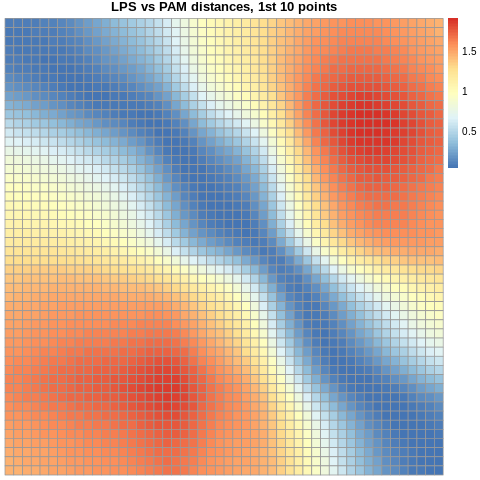

In [46]:
%%R
A=calcDistMat(nucData$interpolatedVals,cellData$interpolatedVals, dist.method = 'Cosine')
pheatmap(A, cluster_cols = F, cluster_rows=F, main = "LPS vs PAM distances, 1st 10 points",
          show_rownames = T, show_colnames = T,display_numbers = F)

R[write to console]: calculate dissimilarity matrix

R[write to console]: calculate cost and step matrices

R[write to console]: backtracking



[1] NA


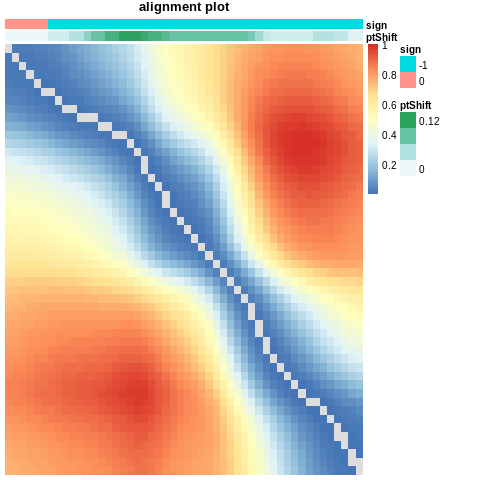

In [47]:
%%R

alignment = globalAlign(nucData$interpolatedVals, cellData$interpolatedVals,
                                   scores = list(query = nucData$traj, 
                                                 ref = cellData$traj),
                                   sigCalc = F, numPerm = 20, dist.method = "Cosine")
plotAlign(alignment)

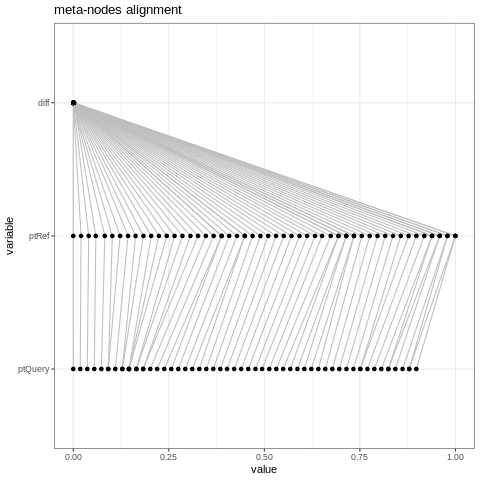

In [48]:
%%R

mapping = mapRealDataGlobal(alignment,intTrajQuery = nucData$traj, realTrajQuery = nucT,
                            intTrajRef = cellData$traj, realTrajRef = cellT)
plotMapping(mapping)

In [49]:
%%R -o mapping
ls(mapping)

[1] "metaNodesPt" "queryAssign" "refAssign"  


In [50]:
mapping['metaNodesPt']['diff']

1     0.000000
2     0.000070
3     0.000430
4     0.002154
5     0.000794
6     0.000241
7     0.000136
8     0.000502
9     0.000302
10    0.000298
11    0.000641
12    0.000634
13    0.000673
14    0.000242
15    0.000066
16    0.000667
17    0.000235
18    0.000109
19    0.000212
20    0.000532
21    0.000450
22    0.000161
23    0.000088
24    0.000011
25    0.000052
26    0.000002
27    0.000039
28    0.000084
29    0.000711
30    0.000101
31    0.000039
32    0.000252
33    0.000518
34    0.000623
35    0.001973
36    0.000341
37    0.000518
38    0.000178
39    0.000131
40    0.000044
41    0.000138
42    0.000116
43    0.000059
44    0.000255
45    0.000265
46    0.000264
47    0.000276
48    0.000185
49    0.000040
50    0.000321
51    0.000283
52    0.000057
53    0.000003
54    0.000350
55    0.000318
56    0.001053
57    0.000050
58    0.000365
59    0.000000
Name: diff, dtype: float64

In [51]:
cellDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptRef']), 
                      index=mapping['metaNodesPt']['metaNodeRef']  )

In [52]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['ptQuery']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [53]:
nucNodes = pd.Series(index=nucNames)
cellNodes = pd.Series(index=cellNames)
for n,c,Tn,Tc in zip(nucDF.index, cellDF.index, nucDF[0], cellDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn
    cellNodes[ mapping['refAssign'][c] ] = Tc

In [54]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.824501
AAACCCACAGATCCTA-Nuclei    0.018276
AAACCCAGTTAGTCGT-Nuclei    0.238113
AAACGAAAGAGCATAT-Nuclei    0.366263
AAACGAAAGCTATCCA-Nuclei    0.256516
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.861837
TTTGTTGGTCCAGCAC-Nuclei    0.457904
TTTGTTGGTCCGTACG-Nuclei    0.622915
TTTGTTGTCGTACACA-Nuclei    0.238113
TTTGTTGTCTGGCCGA-Nuclei    0.128401
Length: 7212, dtype: float64

How to check Nan in the alignment and correction with the nearest neighbour (not a problem in this case)

In [55]:
idxNan = nucNodes.index[ np.where(np.isnan(nucNodes)) ]

In [56]:
idxNan

Index([], dtype='object')

In [57]:
idxNan = cellNodes.index[ np.where(np.isnan(cellNodes)) ]

In [58]:
idxNan

Index([], dtype='object')

correction:

In [59]:
#dist = pd.DataFrame( NUCLEI.uns['neighbors']['distances'].todense(), 
#                    index=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names,
#                    columns=adata_flt[adata_flt.obs['condition']=='nuclei'].obs_names )


In [60]:
#for i in idxNan:
#    gzero = dist.loc[i,:][ dist.loc[i,:]>0 ]
#    nucNodes.loc[ i ] = nucNodes.loc[ np.argmin(gzero) ]

Copying all the binned aligned pseudotimes in the original data object

In [61]:
concatTime = pd.concat([nucNodes, cellNodes])

In [62]:
dpt_cellalign_new = pd.Series(index=adata.obs_names)
dpt_cellalign_new[adata_flt.obs_names] = concatTime

In [63]:
dpt_cellalign_new[ [i not in adata_flt.obs_names for i in dpt_cellalign_new.index] ] = -1

In [64]:
adata.obs['dpt_palantir_magic_cellalign'] = dpt_cellalign_new.copy()

Some fancy plots

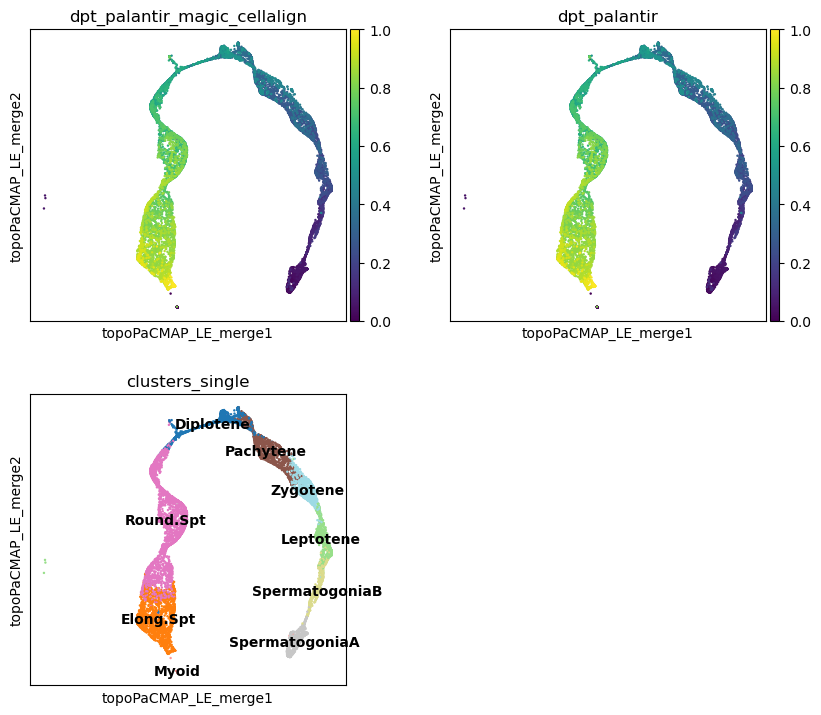

In [65]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=['dpt_palantir_magic_cellalign', 'dpt_palantir', 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
    vmin=0
)

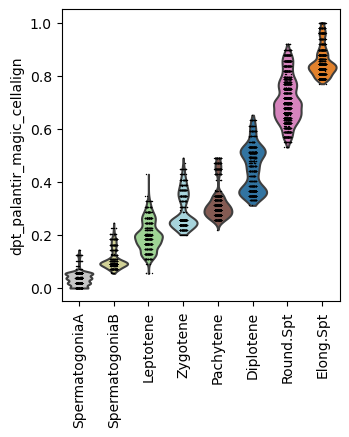

In [66]:
sc.pl.violin(adata, keys='dpt_palantir_magic_cellalign', groupby='clusters_single',
             order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'], rotation=90)

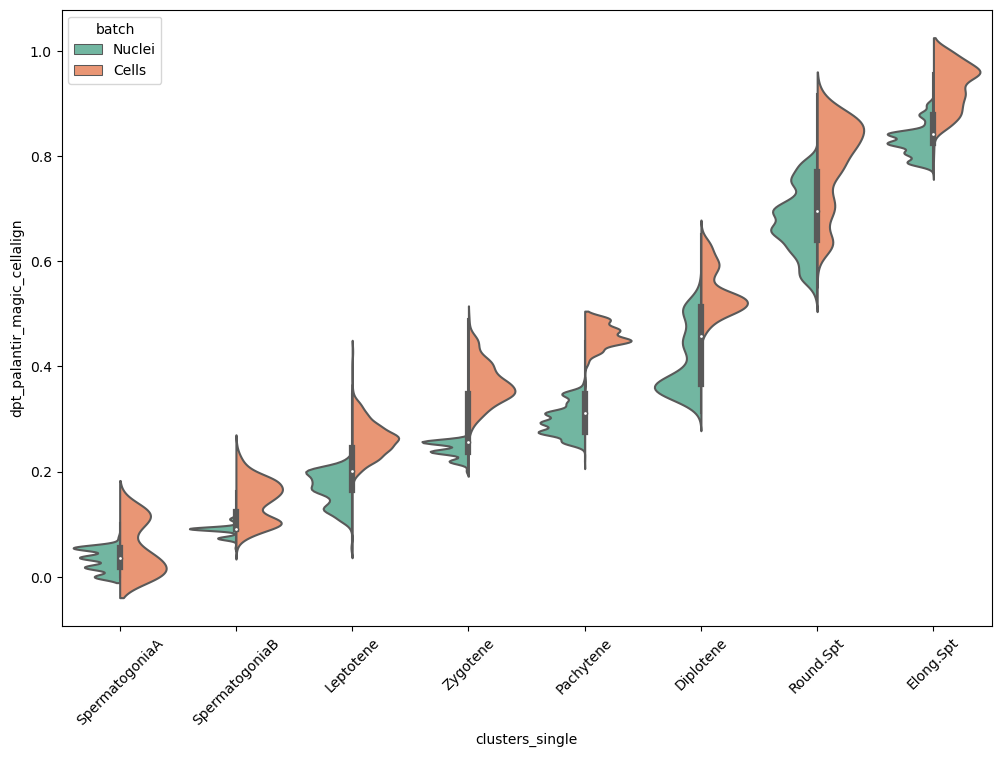

In [67]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir_magic_cellalign", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir_magic_cellalign', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

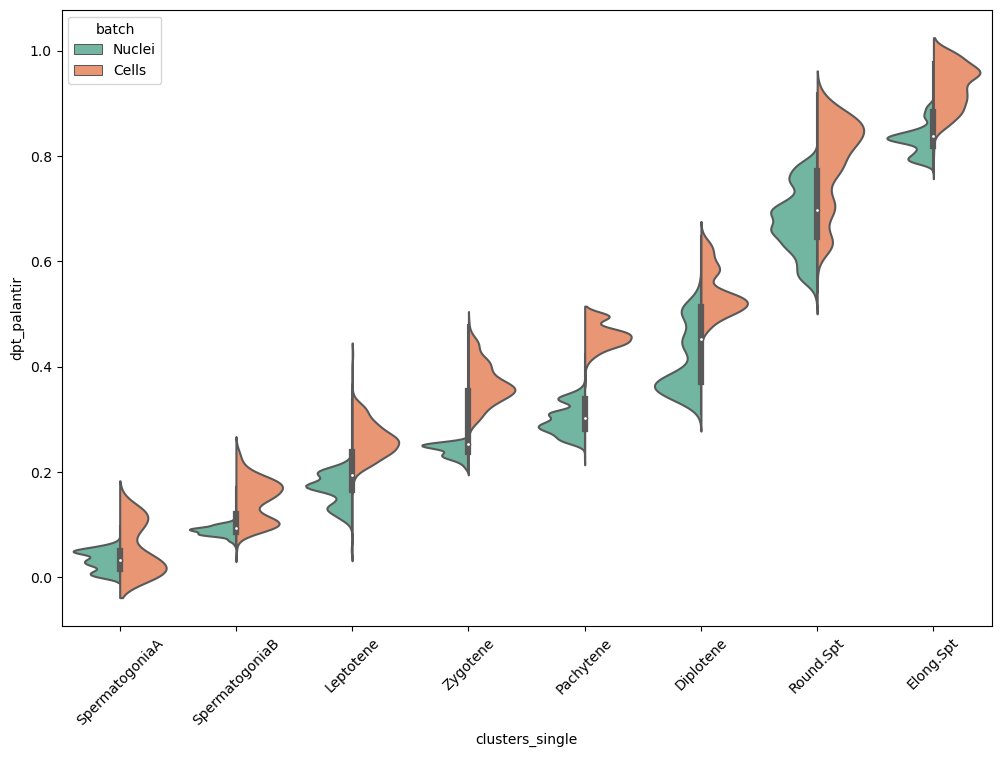

In [68]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_palantir", hue="batch", 
                    scale="width", palette="Set2", split=True, ax=ax1,                    
                    data=adata.obs[ ['batch', 'dpt_palantir', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

In [69]:
adata.write('./write/adata.dpt.magic.h5ad')

We also look at size of differences between pseudotimes to see the size of the correction

In [5]:
adata = sc.read('./write/adata.dpt.magic.h5ad')

Only considering the two last: ['.magic', '.h5ad'].
Only considering the two last: ['.magic', '.h5ad'].


In [71]:
nucDF = pd.DataFrame(np.array(mapping['metaNodesPt']['diff']), 
                      index=mapping['metaNodesPt']['metaNodeQuery']  )

In [72]:
nucNodes = pd.Series(index=nucNames)
for n,Tn in zip(nucDF.index, nucDF[0]):
    nucNodes[ mapping['queryAssign'][n] ] = Tn

In [73]:
nucNodes

AAACCCAAGGACAGCT-Nuclei    0.000350
AAACCCACAGATCCTA-Nuclei    0.000070
AAACCCAGTTAGTCGT-Nuclei    0.000532
AAACGAAAGAGCATAT-Nuclei    0.000039
AAACGAAAGCTATCCA-Nuclei    0.000450
                             ...   
TTTGTTGCACTGCGAC-Nuclei    0.001053
TTTGTTGGTCCAGCAC-Nuclei    0.000252
TTTGTTGGTCCGTACG-Nuclei    0.000138
TTTGTTGTCGTACACA-Nuclei    0.000532
TTTGTTGTCTGGCCGA-Nuclei    0.000298
Length: 7212, dtype: float64

In [74]:
NUCLEI.obs['dpt_diff'] = [nucNodes[i] if i in nucNodes.index 
                          else -1
                          for i in NUCLEI.obs_names]

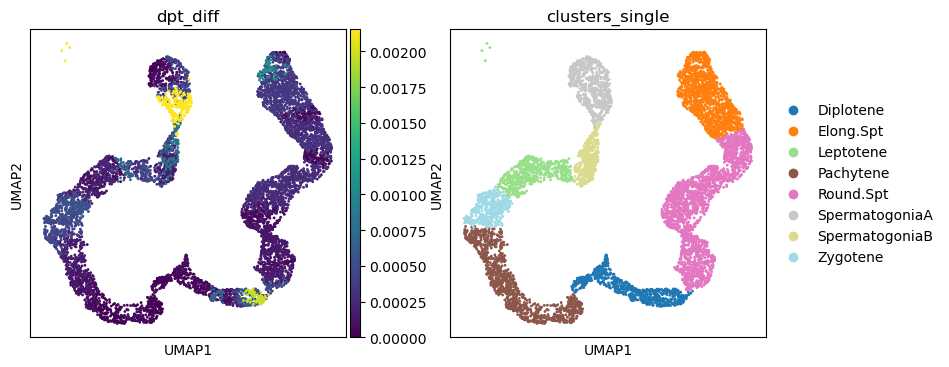

In [75]:
sc.pl.umap(NUCLEI, color=['dpt_diff','clusters_single'], vmin=0)

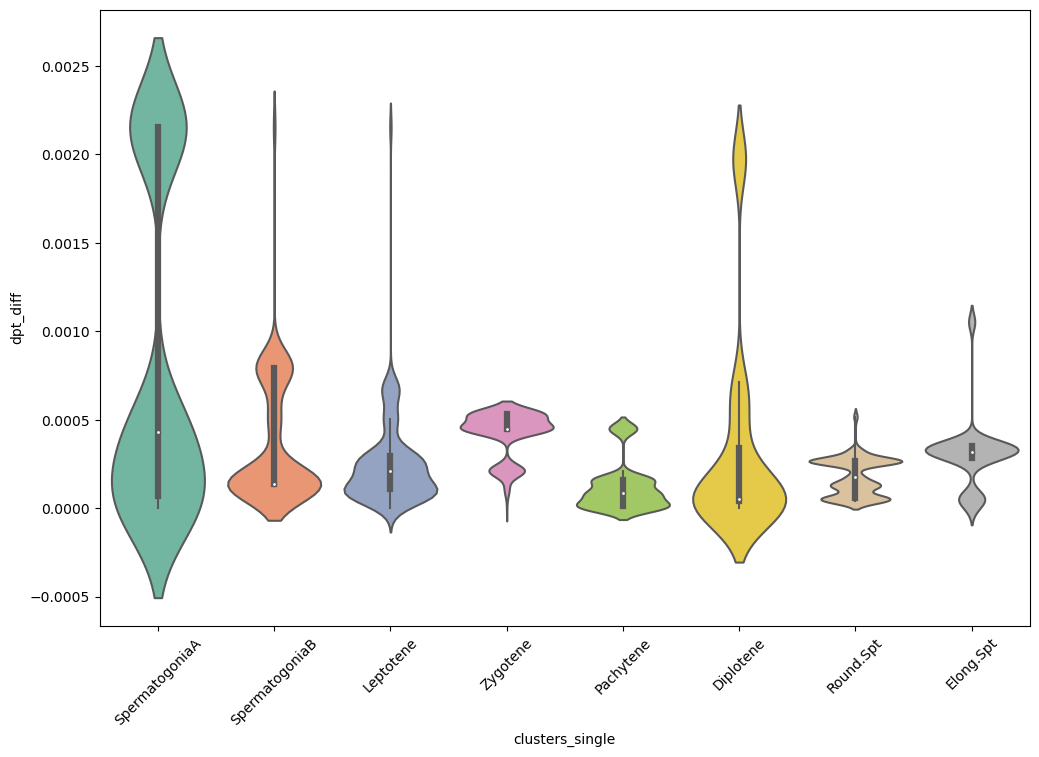

In [77]:
fig, (ax1) = plt.subplots(1, 1, figsize=(12,8), gridspec_kw={'wspace':0.5})
ax = sns.violinplot(x="clusters_single", y="dpt_diff", 
                    scale="width", palette="Set2", ax=ax1,                    
                    data=NUCLEI.obs[ ['dpt_diff', 'clusters_single'] ], 
                    order=['SpermatogoniaA','SpermatogoniaB','Leptotene','Zygotene',
                   'Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'])
ax.tick_params(axis='x', rotation=45)

Almost no difference when using imputation and aligning pseudotimes when comparing with the alignment approach without imputed gene expressions, but most difference is in cell types instead of in the pairs query-reference